In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

# plt.rcParams['figure.facecolor'] = 'black'
# plt.rcParams['axes.facecolor'] = 'black'
# plt.rcParams['axes.edgecolor'] = 'white'
# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['text.color'] = 'white'
# plt.rcParams['grid.color'] = 'white'

pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_03022026_AllSubjects' # to specify the version of the data
#_03022026_AllSubjects
Aging_INDICES = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

DTI=np.zeros((47, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC



In [2]:
Aging_INDICES

,sub,age,group,JND_P,group_M,group_O,group_Y
0,sub-01,25,Y,9.5600,0.0,0.0,1.0
1,sub-02,27,Y,6.6900,0.0,0.0,1.0
2,sub-03,28,Y,12.9200,0.0,0.0,1.0
3,sub-05,21,Y,1.9500,0.0,0.0,1.0
4,sub-06,25,Y,2.5400,0.0,0.0,1.0
5,sub-08,67,O,4.4800,0.0,1.0,0.0
6,sub-09,73,O,9.6300,0.0,1.0,0.0
7,sub-10,64,O,7.2700,0.0,1.0,0.0
8,sub-11,21,Y,1.6200,0.0,0.0,1.0
9,sub-12,21,Y,3.6800,0.0,0.0,1.0


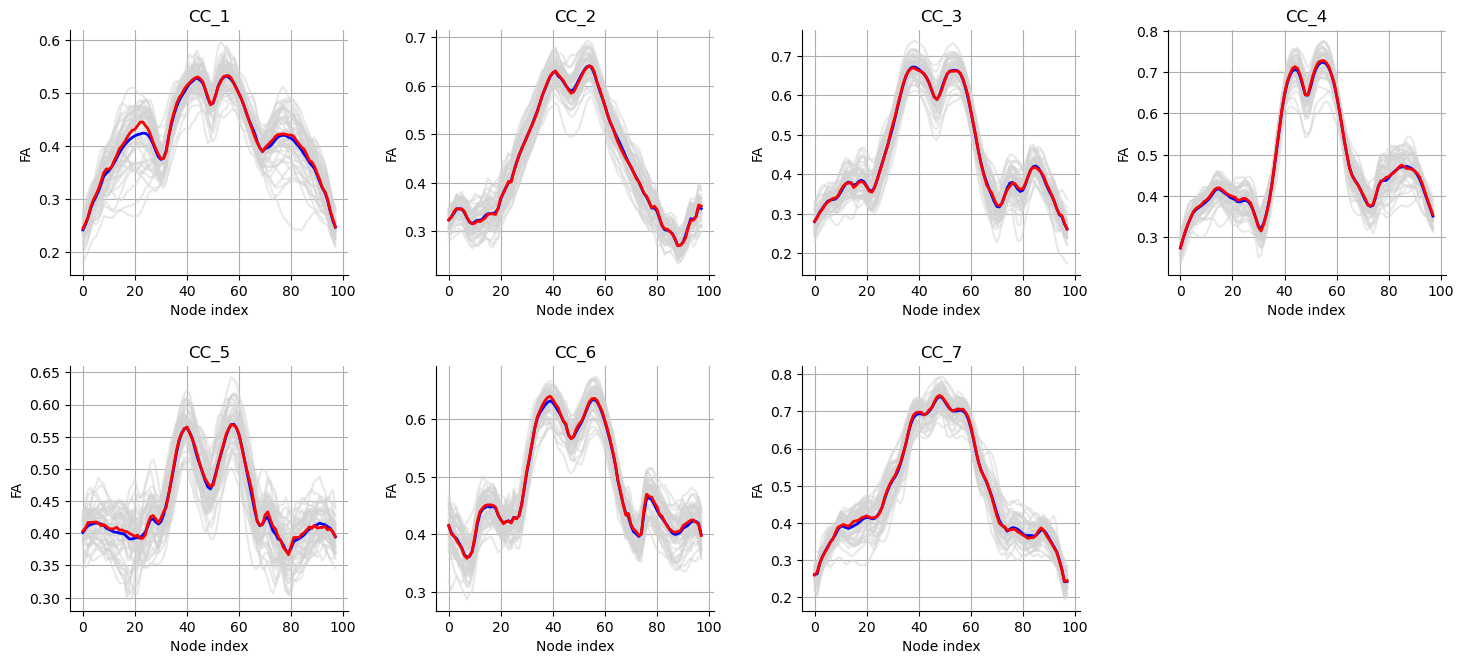

In [3]:
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel('FA')
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)



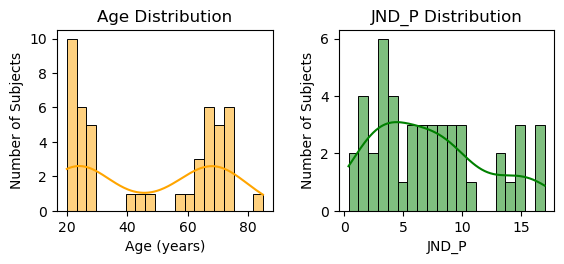

In [4]:
 # target var

import seaborn as sns

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, SelectFromModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.pipeline import Pipeline

labels = [0,1]
Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values
age_grouped = Aging_INDICES['group_O']
jnd_grouped = Aging_INDICES['JND_group']

Aging_INDICES



,sub,age,group,JND_P,group_M,group_O,group_Y,JND_group
0,sub-01,25,Y,9.5600,0.0,0.0,1.0,1
1,sub-02,27,Y,6.6900,0.0,0.0,1.0,0
2,sub-03,28,Y,12.9200,0.0,0.0,1.0,1
3,sub-05,21,Y,1.9500,0.0,0.0,1.0,0
4,sub-06,25,Y,2.5400,0.0,0.0,1.0,0
5,sub-08,67,O,4.4800,0.0,1.0,0.0,0
6,sub-09,73,O,9.6300,0.0,1.0,0.0,1
7,sub-10,64,O,7.2700,0.0,1.0,0.0,1
8,sub-11,21,Y,1.6200,0.0,0.0,1.0,0
9,sub-12,21,Y,3.6800,0.0,0.0,1.0,0


In [1]:
from sklearn.datasets import make_friedman1
from sklearn.feature_selection import RFE
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

random_state=np.random.randint(0,100)
print(f'Random state for reproducibility: {random_state}')

target=['age', 'jnd']
figure, axs = plt.subplots(nrows=7, ncols=2, figsize=(10, 18))

RFE_ranked_feat_allCC_tgt=[]

for t in target:
    if t=='age':
        y=age
        axsy=0
    elif t=='jnd':
        y=jnd
        axsy=1
    ranked_feat_allCC=[]
    
    for cc in range(7):
        print(f'Processing target {t} CC {cc+1}')
        X=DTI[:,:,cc]     # Features (independent variable)
            
        # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

        scaler = StandardScaler()
        # X_train_scaled = scaler.fit_transform(X_train)
        # X_test_scaled = scaler.transform(X_test)
        X_scaled = scaler.fit_transform(X)
        # if t=='jnd':
        # estimator = SVR(kernel="linear")
        estimator = XGBRegressor()
       
        selector = RFE(estimator, n_features_to_select=10, step=1)
        print(f'RFE from SVR linear for JND: Processing target {t} CC {cc+1}')

        # selector = selector.fit(X_train, y_train)
        selector = selector.fit(X, y)

        selector.support_
        selector.ranking_
        ranked_feat_allCC.append(selector.ranking_)

        np.where(selector.ranking_<10)[0].tolist()
        
        axs[cc, axsy].bar(np.arange(98), 100-selector.ranking_)
        axs[cc, axsy].axhline(90, color='red', linestyle='--')  
        axs[cc, axsy].set_xlabel("Feature number")
        axs[cc, axsy].set_ylabel(f'CC {cc+1} RFE ranking') 
        axs[cc, axsy].spines['top'].set_visible(False)
        axs[cc, axsy].spines['right'].set_visible(False)

    axs[0, axsy].set_title(f' RFE & SVR Linear Feature ranking : target {t} ')
    plt.tight_layout(pad=2.0)

    RFE_ranked_feat_allCC_tgt.append(ranked_feat_allCC)



NameError: name 'np' is not defined

In [38]:
np.where(RFE_ranked_feat_allCC_tgt[1][5]<2)[0].tolist()

[5, 7, 17, 29, 43, 45, 62, 75, 86, 93]

create an array Xbest with the x best features of each CC

In [26]:
allbestfeat_cc=[[],[]]
last10from70_DTI=np.zeros((2,10))
matrice_finale=np.zeros((2, 47, 70)) # 2 targets x 47 subjects x 70 features (10 features x 7 CC)
for tgt_idx, tgt in enumerate(target):

    if tgt=='age':
        y=age

    elif tgt=='jnd':
        y=jnd

    matrices = [DTI[:,RFE_ranked_feat_allCC_tgt[tgt_idx][cc]<2,cc] for _ in range(7)]  # Exemple avec des matrices aléatoires
    
    for cc in range(7):
        allbestfeat_cc[tgt_idx].append(np.where(RFE_ranked_feat_allCC_tgt[tgt_idx][cc]<2)[0].tolist())

    matrice_finale[tgt_idx] = np.hstack(matrices)
    matrice_finale.shape

   
    X=matrice_finale[tgt_idx]    # Features (independent variable)
            
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=random_state)

    scaler = StandardScaler()
    X_scaled=scaler.fit_transform(X)
    # X_train_scaled = scaler.fit_transform(X_train)
    # X_test_scaled = scaler.transform(X_test)

    # if t=='jnd':
    
    # estimator = SVR(kernel="linear")    
    estimator = XGBRegressor()   

    
    selector = RFE(estimator, n_features_to_select=10, step=1)
    print(f'RFE from SVR linear for JND: Processing target {tgt} ')

    selector = selector.fit(X_scaled, y)

    last10from70_DTI[tgt_idx,:]=np.where(selector.ranking_<2)[0].tolist()
 


#     sns.scatterplot(x=y, y=X_scaled[:,31])
#     plt.show()

# print(last10from70_DTI)
# matrice_finale.shape


RFE from SVR linear for JND: Processing target age 
RFE from SVR linear for JND: Processing target jnd 


In [31]:
for tgt_idx, tgt in enumerate(target):
    print(f'Best features for target {tgt} :')
    for cc in range(7):
        print(np.where(RFE_ranked_feat_allCC_tgt[tgt_idx][cc]<2)[0].tolist())

last10from70_DTI

Best features for target age :
[4, 13, 14, 18, 28, 33, 52, 54, 68, 85]
[0, 10, 11, 12, 22, 47, 73, 81, 86, 94]
[10, 15, 17, 22, 37, 38, 64, 65, 66, 90]
[6, 43, 50, 69, 71, 75, 76, 83, 84, 96]
[0, 8, 38, 53, 57, 60, 70, 72, 76, 96]
[0, 1, 14, 16, 20, 21, 84, 87, 88, 90]
[1, 10, 11, 17, 21, 30, 72, 73, 87, 93]
Best features for target jnd :
[2, 5, 14, 45, 61, 63, 65, 66, 82, 84]
[7, 8, 22, 25, 69, 81, 85, 86, 87, 94]
[0, 1, 7, 13, 14, 20, 22, 23, 27, 92]
[8, 10, 20, 25, 47, 66, 67, 77, 81, 90]
[5, 6, 16, 30, 33, 45, 58, 69, 82, 91]
[5, 7, 17, 29, 43, 45, 62, 75, 86, 93]
[11, 12, 13, 14, 37, 41, 48, 60, 87, 95]


array([[0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]])

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

nseeds=50

# Charger les données
MSEall = np.zeros((2,2,nseeds), dtype=object)  
MAEall = np.zeros((2,2,nseeds), dtype=object)

for tgt_idx, tgt in enumerate(target):

    if tgt=='age':
        y = age  # Target variable (dependent variable)
    elif tgt=='jnd':
        y = jnd  # Target variable (dependent variable)

    print(f'Processing target {tgt} with XGBRegressor for {nseeds} seeds')

    for bestfrom in [0,1]:    
        X = matrice_finale[bestfrom]   # Features (independent variable)

        for seed in range(nseeds):
                
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

            model = XGBRegressor()
            model.fit(X_train, y_train)
            predictions = model.predict(X_test)

            # Évaluer le modèle
            MSEall[tgt_idx, bestfrom, seed] = mean_squared_error(y_test, predictions)
            MAEall[tgt_idx, bestfrom, seed] = mean_absolute_error(y_test, predictions)


Processing target age with XGBRegressor for 50 seeds
Processing target jnd with XGBRegressor for 50 seeds


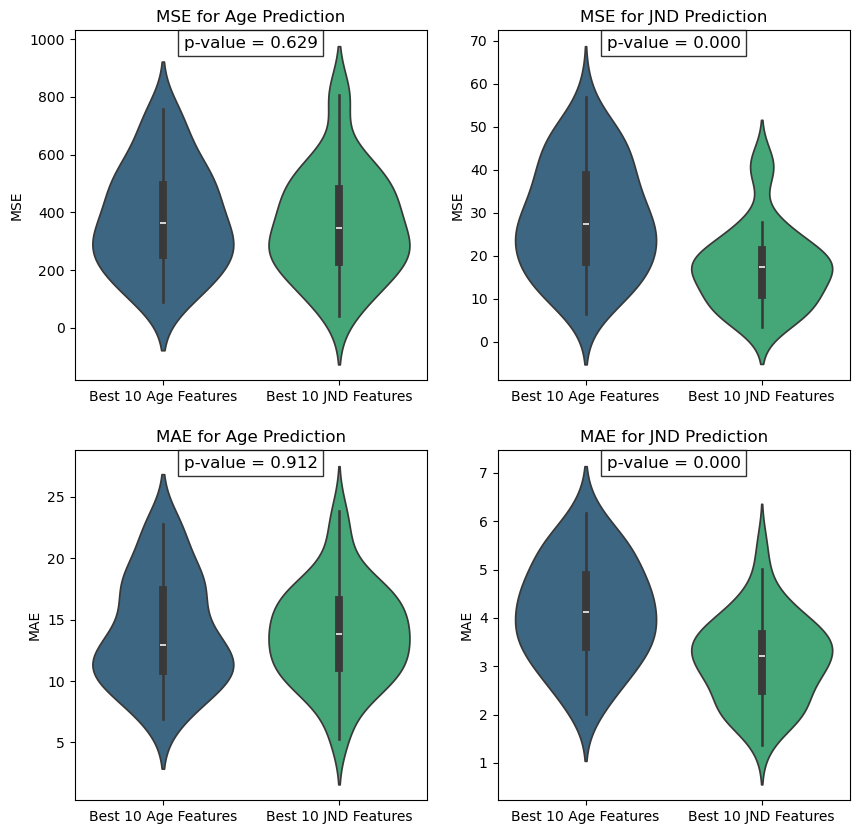

In [30]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

Metric_name=['MSE', 'MAE']

for metric_idx, metric in enumerate(Metric_name):
    if metric=='MSE':
        Metric_var=MSEall
    elif metric=='MAE':
        Metric_var=MAEall


    sns.violinplot(data=[Metric_var[0,0], Metric_var[0,1]],  palette='viridis', ax=axs[metric_idx,0])
    axs[metric_idx,0].set_title(f'{metric} for Age Prediction')
    axs[metric_idx,0].set_xticklabels(['Best 10 Age Features', 'Best 10 JND Features'])
    axs[metric_idx,0].set_ylabel(f'{metric}')

    sns.violinplot(data=[Metric_var[1,0], Metric_var[1,1]], palette='viridis', ax=axs[metric_idx,1])
    axs[metric_idx,1].set_title(f'{metric} for JND Prediction')
    axs[metric_idx,1].set_xticklabels(['Best 10 Age Features', 'Best 10 JND Features'])
    axs[metric_idx,1].set_ylabel(f'{metric}')

    from scipy.stats import kruskal


    statistic, p_value = kruskal(Metric_var[0,0], Metric_var[0,1])

    axs[metric_idx,0].text(0.5, 0.95, f'p-value = {p_value:.3f}',
                transform=axs[metric_idx,0].transAxes, ha='center', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.8))



    statistic, p_value = kruskal(Metric_var[1,0], Metric_var[1,1])

    axs[metric_idx,1].text(0.5, 0.95, f'p-value = {p_value:.3f}',
                transform=axs[metric_idx,1].transAxes, ha='center', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.8))


    

In [11]:
print(last10from70_DTI)
matrice_finale.shape

[[19. 29. 39. 43. 49. 53. 59. 63. 65. 69.]
 [ 8. 20. 26. 33. 36. 40. 43. 48. 53. 56.]]


(2, 47, 70)

In [12]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import random
from scipy.stats import ttest_ind


target=['jnd','age']  # 'age' or 'jnd'


for target in target:
    print("Target:", target)


    if target=='age':
            SelectedFeat=ranked_feat_allCC_tgt[0]
    elif target=='jnd':
            SelectedFeat=ranked_feat_allCC_tgt[1]
                            

    # CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

    figure, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))
    axs = axs.flatten()
    for CC in range(1,8):
            
        CCx=f'CC_{CC}'
        CCxindex=CC-1
        SelectedFeatonecc=SelectedFeat[CCxindex]


        axs[CCxindex].plot(DTI[:,:,CCxindex].T, color='lightgray', alpha=0.5)
        axs[CCxindex].plot(DTI[:,:,CCxindex].mean(axis=0), color='blue', linewidth=2)

        axs[CCxindex].plot(np.where(SelectedFeatonecc<5)[0],DTI[:,np.where(SelectedFeatonecc<5)[0],CCxindex].mean(axis=0), 'ro')

        axs[CCxindex].set_xlabel('Node index')
        axs[CCxindex].set_ylabel('FA')
        axs[CCxindex].grid(True)  
        axs[CCxindex].spines['top'].set_visible(False)
        axs[CCxindex].spines['right'].set_visible(False)
        axs[CCxindex].set_title(f'CC {CC} - Feature selection ')
        axs[CCxindex].set_title(CCx)

    figure.suptitle(f'Feature selection for target {target}', fontsize=16)

    axs[7].axis('off')
    plt.tight_layout(pad=2.0)


Target: jnd


NameError: name 'ranked_feat_allCC_tgt' is not defined